# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [13]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [14]:
# Inspect the shapes of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

#sanity checks 
print("y_train shape:", y_train.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
y_train shape: (60000, 10)


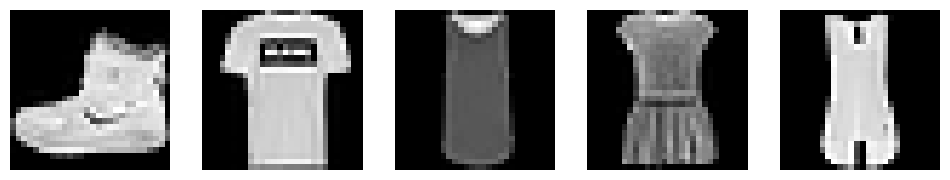

In [20]:
import matplotlib.pyplot as plt

# 1 row with 5 images 
fig, axes = plt.subplots(1, 5, figsize=(12, 3)) 

for i, ax in enumerate(axes):
    ax.imshow(X_train[i], cmap='gray')                                
    ax.axis("off")
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

It does look as I expected, the quality of the image is a bit iffy ( not the greatest), but I can see identify each piece. I guess one major concern here is that the pullover is not much different than than a tank top? (i.e., picture 5 and 3 )

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [23]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10, activation='softmax'))
# Compile the model using `model.compile()`
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)
# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 602us/step - accuracy: 0.7211 - loss: 0.8788 - val_accuracy: 0.7865 - val_loss: 0.6577
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 435us/step - accuracy: 0.8004 - loss: 0.6161 - val_accuracy: 0.8077 - val_loss: 0.5831
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 469us/step - accuracy: 0.8174 - loss: 0.5611 - val_accuracy: 0.8152 - val_loss: 0.5502
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 439us/step - accuracy: 0.8258 - loss: 0.5321 - val_accuracy: 0.8211 - val_loss: 0.5282
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 419us/step - accuracy: 0.8306 - loss: 0.5128 - val_accuracy: 0.8278 - val_loss: 0.5090
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step - accuracy: 0.8206 - loss: 0.5334
Loss:     0.53
Accuracy: 82.06%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

The test accuracy was 72%. It is somehwat what I expected since I can still differentiate different clothign categories at a glance, although with not 100% certainty (i.e., image 3 and 5). I believe performance might be at this level perhaps because the model is still underfitting ( it is still linear, accuracy was still rising at epoch 5)

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [25]:
from keras.layers import Conv2D, Flatten, Dense

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
#using 32 filters 
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)
# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

/Users/lilianawu/DSI_ML/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8499 - loss: 0.4277 - val_accuracy: 0.8782 - val_loss: 0.3398
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8939 - loss: 0.2993 - val_accuracy: 0.8933 - val_loss: 0.3016
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9074 - loss: 0.2591 - val_accuracy: 0.8945 - val_loss: 0.3059
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9183 - loss: 0.2287 - val_accuracy: 0.8997 - val_loss: 0.2894
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9253 - loss: 0.2053 - val_accuracy: 0.9028 - val_loss: 0.2845
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - accuracy: 0.8954 - loss: 0.2955
Loss:     0.30
Accuracy: 89.54%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

YAY it did perform better \o/ about 7%! I believe the Conv2D layer learns spatial features (i.e., edges, shapes, textures). 

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [27]:
# A. Test Hyperparameters

#import
from keras.layers import Conv2D, Flatten, Dense
from keras.models import Sequential

#let's define a builder.
def build_cnn(num_filters):
    model = Sequential()
    model.add(Conv2D(num_filters, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

#empty array to store filter results
filter_results = {}
#using the number of filters suggested?
for num_filters in [32, 64, 128]:
    # FRESH model each time
    model = build_cnn(num_filters)                     
    model.fit(X_train, y_train, epochs=5, batch_size=32,
              validation_split=0.2)          
    loss, acc = model.evaluate(X_test, y_test)
    filter_results[num_filters] = acc
    print(f"{num_filters} filters -> test accuracy: {acc*100:.2f}%")

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8508 - loss: 0.4216 - val_accuracy: 0.8799 - val_loss: 0.3351
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8944 - loss: 0.2949 - val_accuracy: 0.8914 - val_loss: 0.3029
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9068 - loss: 0.2578 - val_accuracy: 0.8976 - val_loss: 0.2911
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9170 - loss: 0.2313 - val_accuracy: 0.8974 - val_loss: 0.2900
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9259 - loss: 0.2089 - val_accuracy: 0.8995 - val_loss: 0.2905
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - accuracy: 0.8941 - loss: 0.3042
32 filters -> test accuracy: 89.41%
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8587 - loss: 0.4027 - val_accuracy: 0.8789 - val_loss: 0.3425
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8989 - loss: 0.2819 - val_accuracy: 0.8930 - v

In [28]:
# B. Test presence or absence of regularization

from keras.layers import Conv2D, Flatten, Dense, Dropout

#define a builder again
def build_cnn(use_dropout):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(Flatten())
    if use_dropout:
        # to switch off half of the neurons during training 
        model.add(Dropout(0.5))          
    model.add(Dense(10, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

dropout_results = {}
for yes_dropout in [False, True]:
    label = "yes dropout" if yes_dropout else "no dropout"
    model = build_cnn(yes_dropout)
    history = model.fit(X_train, y_train, epochs=5, batch_size=32,
                        validation_split=0.2)
    loss, acc = model.evaluate(X_test, y_test)
    # capture the train/val gap on the last epoch ? 
    gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    dropout_results[label] = (acc, gap)
    print(f"{label}: test acc {acc*100:.2f}%, train/val gap {gap*100:.2f}%")


/Users/lilianawu/DSI_ML/deep_learning/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8513 - loss: 0.4157 - val_accuracy: 0.8813 - val_loss: 0.3313
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8958 - loss: 0.2911 - val_accuracy: 0.8947 - val_loss: 0.3024
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9080 - loss: 0.2553 - val_accuracy: 0.8923 - val_loss: 0.2971
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9176 - loss: 0.2281 - val_accuracy: 0.8993 - val_loss: 0.2863
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9255 - loss: 0.2077 - val_accuracy: 0.9006 - val_loss: 0.2882
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8976 - loss: 0.2990
no dropout: test acc 89.76%, train/val gap 2.49%
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8459 - loss: 0.4398 - val_accuracy: 0.8812 - val_loss: 0.3355
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8873 - loss: 0.3154 - val_accuracy:

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

For experiment A it seems like changing the filter did not improve the model performance, accuracy was around 89%. For expariment B, dropout reduced the  train/val gap from 2.49% to 1.05% ( i.e., less overfitting), but the test accuracy also decreased slightly....  I think the best combination is 32 filters and no dropout. 

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [29]:
from keras.layers import Conv2D, Flatten, Dense
from keras.models import Sequential


final_model = Sequential()
final_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
final_model.add(Flatten())
final_model.add(Dense(10, activation='softmax'))

final_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

final_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)

loss, accuracy = final_model.evaluate(X_test, y_test)
print(f'Final model test accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8521 - loss: 0.4223 - val_accuracy: 0.8773 - val_loss: 0.3418
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8957 - loss: 0.2938 - val_accuracy: 0.8888 - val_loss: 0.3117
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9093 - loss: 0.2533 - val_accuracy: 0.8946 - val_loss: 0.2985
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9192 - loss: 0.2222 - val_accuracy: 0.8942 - val_loss: 0.3049
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9288 - loss: 0.2000 - val_accuracy: 0.8968 - val_loss: 0.2933
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.8913 - loss: 0.3058
Final model test accuracy: 89.13%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

Compared to baseline the final model (89%) beats it by 7%, which essentially matches the CNN accuracy. I believe what contributed was the Cov2D feature, making the model distinguish visually similar clothes through spatial features (i.e., edges, shapes). The Filter and drop out options made little differences here. 

Perhaps an additional experiment would be adding a second Cov layer or adding more ephocs. 

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.